In [3]:
pip install bambi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 22.6 MB/s eta 0:00:00


In [4]:
import pandas as pd

url = "https://peopleanalytics-regression-book.org/data/absenteeism.csv"
abs_df = pd.read_csv(url)

print(abs_df.head())
print()
print(abs_df.info())
print()
print(abs_df.describe(include="all"))

   days_absent  tenure  is_manager  performance_rating
0            2      16           0                   2
1           13       4           0                   5
2            0       0           0                   3
3            8      24           0                   5
4           12       9           0                   3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   days_absent         865 non-null    int64
 1   tenure              865 non-null    int64
 2   is_manager          865 non-null    int64
 3   performance_rating  865 non-null    int64
dtypes: int64(4)
memory usage: 27.2 KB
None

       days_absent      tenure  is_manager  performance_rating
count   865.000000  865.000000  865.000000          865.000000
mean     10.262428   15.161850    0.129480            3.472832
std      10.161396    8.955222    0.335924       

In [2]:
# take a sample of 100 observations
absenteeism_bayes = abs_df.sample(n=100, random_state=123).copy()

# quick check
print(absenteeism_bayes.head())
print()
print(absenteeism_bayes.shape)

     days_absent  tenure  is_manager  performance_rating
227           16      30           1                   5
598            8      23           0                   4
280            2       8           0                   3
52             5       1           0                   4
162           12      23           0                   3

(100, 4)


In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# fit Poisson regression
pois_glm = smf.glm(
    formula="days_absent ~ tenure + is_manager + performance_rating",
    data=absenteeism_bayes,
    family=sm.families.Poisson()
).fit()

# summary
print(pois_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            days_absent   No. Observations:                  100
Model:                            GLM   Df Residuals:                       96
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -466.11
Date:                Thu, 16 Apr 2026   Deviance:                       558.63
Time:                        23:44:20   Pearson chi2:                     578.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.8405
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.5718      0

In [6]:
# expected number of days absent
pred_counts = pois_glm.predict(absenteeism_bayes)

print(pred_counts.head())

227    16.337190
598    13.188175
280     6.463061
52      4.402230
162    13.656293
dtype: float64


In [7]:
from scipy.stats import poisson

# example: probability of exactly 3 absences for first observation
lambda_0 = pred_counts.iloc[0]

poisson.pmf(3, mu=lambda_0)

np.float64(5.837533804743053e-05)

In [8]:
import bambi as bmb

# define model
pois_model = bmb.Model(
    "days_absent ~ tenure + is_manager + performance_rating",
    data=absenteeism_bayes,
    family="poisson"
)

# fit model
pois_results = pois_model.fit()

Output()

In [9]:
import arviz as az

az.summary(pois_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.569,0.142,1.297,1.829,0.002,0.003,3456.0,1549.0,1.0
is_manager,-0.103,0.086,-0.259,0.062,0.002,0.002,2603.0,1451.0,1.0
performance_rating,-0.035,0.039,-0.113,0.034,0.001,0.001,2810.0,1725.0,1.0
tenure,0.050,0.004,0.042,0.057,0.000,0.000,1800.0,1522.0,1.0


In [11]:
# generate posterior predictive samples
idata_pois = pois_model.predict(pois_results, kind="pps")

/usr/local/lib/python3.12/dist-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


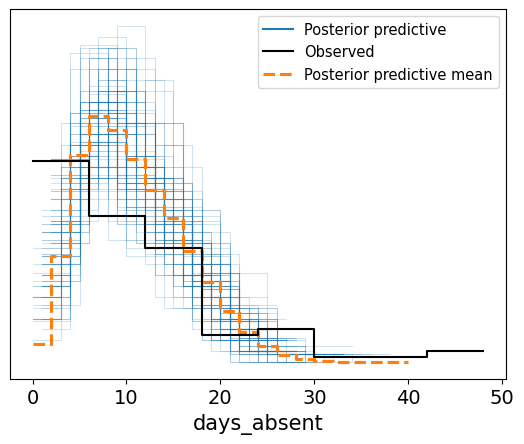

In [12]:
import arviz as az
import matplotlib.pyplot as plt

# posterior predictive samples
idata_pois = pois_results

# posterior predictive check
az.plot_ppc(idata_pois, num_pp_samples=100)
plt.show()

In [14]:
import bambi as bmb

# define model
negbin_model = bmb.Model(
    "days_absent ~ tenure + is_manager + performance_rating",
    data=absenteeism_bayes,
    family="negativebinomial"
)

# fit model
negbin_results = negbin_model.fit()

Output()

In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# fit Negative Binomial with estimated alpha
negbin_mle = smf.negativebinomial(
    formula="days_absent ~ tenure + is_manager + performance_rating",
    data=absenteeism_bayes
).fit()

print(negbin_mle.summary())

Optimization terminated successfully.
         Current function value: 3.217118
         Iterations: 17
         Function evaluations: 19
         Gradient evaluations: 19
                     NegativeBinomial Regression Results                      
Dep. Variable:            days_absent   No. Observations:                  100
Model:               NegativeBinomial   Df Residuals:                       96
Method:                           MLE   Df Model:                            3
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.04179
Time:                        00:46:15   Log-Likelihood:                -321.71
converged:                       True   LL-Null:                       -335.74
Covariance Type:            nonrobust   LLR p-value:                 3.531e-06
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             

In [15]:
import arviz as az

az.summary(negbin_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.496,0.335,0.885,2.135,0.007,0.007,2584.0,1611.0,1.0
alpha,2.001,0.364,1.397,2.700,0.008,0.008,2488.0,1633.0,1.0
is_manager,-0.120,0.216,-0.538,0.274,0.004,0.004,2440.0,1760.0,1.0
performance_rating,-0.012,0.091,-0.187,0.160,0.002,0.002,2148.0,1513.0,1.0
tenure,0.050,0.009,0.034,0.068,0.000,0.000,2072.0,1830.0,1.0


In [21]:
print(negbin_results)
print(negbin_results.posterior_predictive)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 2MB
Dimensions:      (chain: 2, draw: 1000, __obs__: 100)
Coordinates:
  * chain        (chain) int64 16B 0 1
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * __obs__      (__obs__) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    days_absent  (chain, draw, __obs__) int64 2MB 1 4 13 6 15 5 ... 13 3 6 24 17
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.17.2


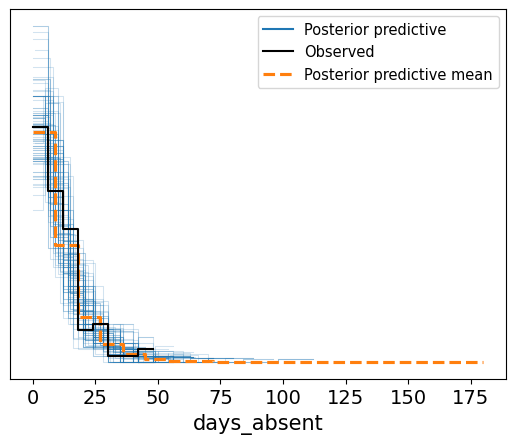

In [22]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_ppc(negbin_results, num_pp_samples=100)
plt.show()